To accomplish this, i used the CRISP-DM methodology focusing on maize as the target staple commodity.

## **1. Business & Data Understanding**
-  **Business Goal:** predict the average future price of key food commodities to assisr with food security tracking and economic planning.
- **Data Setup:** The dataset includes geographic markets, commoditytypes, price variations. We narrowed the scope down to the country-wide monthly average price of maize(white), a crucial staple food in kenya.



In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# load data
df = pd.read_csv('wfp_food_prices_ken.csv')
print(df.head())
print("\n")
print(df.tail())

         date   admin1   admin2   market  market_id  latitude  longitude  \
0  2006-01-15    Coast  Mombasa  Mombasa        191     -4.05      39.67   
1  2006-01-15    Coast  Mombasa  Mombasa        191     -4.05      39.67   
2  2006-01-15  Eastern    Kitui    Kitui        187     -1.37      38.02   
3  2006-01-15  Eastern    Kitui    Kitui        187     -1.37      38.02   
4  2006-01-15  Eastern    Kitui    Kitui        187     -1.37      38.02   

             category         commodity  commodity_id   unit priceflag  \
0  cereals and tubers     Maize (white)            67  90 KG    actual   
1     pulses and nuts       Beans (dry)           262  90 KG    actual   
2  cereals and tubers     Maize (white)            67     KG    actual   
3  cereals and tubers  Potatoes (Irish)           148  50 KG    actual   
4  cereals and tubers           Sorghum            65  90 KG    actual   

   pricetype currency    price  usdprice  
0  Wholesale      KES  1480.00     20.58  
1  Wholesale

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17896 entries, 0 to 17895
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          17896 non-null  str    
 1   admin1        17853 non-null  str    
 2   admin2        17853 non-null  str    
 3   market        17896 non-null  str    
 4   market_id     17896 non-null  int64  
 5   latitude      17853 non-null  float64
 6   longitude     17853 non-null  float64
 7   category      17896 non-null  str    
 8   commodity     17896 non-null  str    
 9   commodity_id  17896 non-null  int64  
 10  unit          17896 non-null  str    
 11  priceflag     17896 non-null  str    
 12  pricetype     17896 non-null  str    
 13  currency      17896 non-null  str    
 14  price         17896 non-null  float64
 15  usdprice      17896 non-null  float64
dtypes: float64(4), int64(2), str(10)
memory usage: 2.2 MB


In [30]:
# statistical summary
df.describe()

,market_id,latitude,longitude,commodity_id,price,usdprice
count,17896.000000,17853.000000,17853.000000,17896.000000,17896.000000,17896.000000
mean,3993.781851,0.723217,37.002449,294.063701,1327.962249,12.198234
std,3162.473315,2.284175,2.032692,292.160300,2591.453113,23.128505
min,184.000000,-4.660000,34.360000,50.000000,5.000000,0.039000
25%,1850.000000,-1.270000,34.860000,67.000000,67.955000,0.600000
50%,3254.000000,0.280000,36.790000,148.000000,130.000000,1.040000
75%,5670.000000,3.390000,38.800000,440.000000,1152.230000,11.032500
max,10509.000000,4.620000,41.860000,937.000000,18900.000000,145.900000


## **2. Data Preparation**

Filtered the dataset for ***Maize (white)***.

Converted the ***date*** column into a proper datetime format.

Aggregated data into average monthly prices.

Re-indexed the dataset to guarantee a continuous monthly frequency and applied linear interpolation to fill in any missing historical months.

In [31]:
# Data preparation 
maize_df = df[df['commodity'] == 'Maize (white)'].copy()
maize_df['date'] = pd.to_datetime(maize_df['date'])

In [32]:
# Aggregate vaerage monthly price 
monthly_price = maize_df.groupby(maize_df['date'].dt.to_period('M'))['price'].mean().reset_index()
monthly_price['date'] = monthly_price['date'].dt.to_timestamp()
monthly_price.set_index('date', inplace=True)


In [33]:
# Reindex to ensure continuous frequency & interprete missig 
full_range = pd.date_range(start=monthly_price.index.min(), end=monthly_price.index.max(), freq='MS')
monthly_price = monthly_price.reindex(full_range)
monthly_price['price'] = monthly_price['price'].interpolate(method='linear')


## **3. Modeling**

- **Algorithm:** We applied a ***SARIMA*** (Seasonal Autoregressive Integrated Moving Average) model to capture both the general trend and any yearly seasonal impacts on maize crops.

- **Data Split:** The data was split sequentially using the first 80% of the timeline for training and the remaining 20% for testing.

- **Parameters used:** SARIMAX(order=(1, 1, 1), seasonal_order=(1, 1, 0, 12)) to account for a 12-month seasonality structure.

In [34]:
# 3. Modeling
train_size = int(len(monthly_price) * 0.8)
train, test = monthly_price.iloc[:train_size], monthly_price.iloc[train_size:]

In [35]:
# fit SARIMA Model
model = SARIMAX (train['price'], order=(1, 1, 1), seasonal_order=(1, 1, 0, 12))
results = model.fit(disp=False)


## **4. Evaluation**

- We forcasted values values over the testing timeline and evaluated the performance.
- The baseline SARIMA model achieved a ***Mean Absolute Error (MAE)*** of 1,101.63 KES and a ***Root Mean Squared Error (RMSE)*** of 1,321.28 KES

In [36]:
# Evalaution
preds = results.predict(start=len(train), end=len(monthly_price)-1, dynamic=False)

mae = mean_absolute_error(test['price'], preds)
rmse = np.sqrt(mean_squared_error(test['price'], preds))
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Mean Absolute Error (MAE): 1101.64
Root Mean Squared Error (RMSE): 1321.29


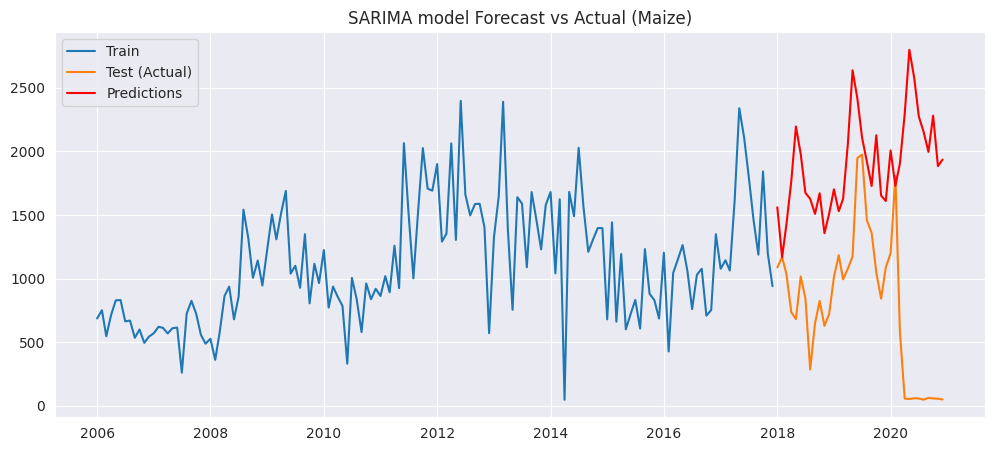

In [37]:
import seaborn as sns
sns.set_style('darkgrid')

# Plotting the forecast
plt.figure(figsize=(12, 5))
plt.plot(train.index, train['price'], label='Train')
plt.plot(test.index, test['price'], label='Test (Actual)')
plt.plot(test.index, preds, label='Predictions', color='red')
plt.title('SARIMA model Forecast vs Actual (Maize)')
plt.legend()
plt.show()